In [144]:
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter("ignore")
import matplotlib.pyplot as plt
import seaborn as sns

In [145]:
df = pd.read_csv("hotel_dataset.csv")
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [146]:
df.columns

Index(['Booking_ID', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status'],
      dtype='str')

##### SIMPLE EDA

In [147]:
df["booking_status"].value_counts()

booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64

In [148]:
df.isnull().sum()

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [149]:
duplicates = df.duplicated()
print(duplicates)

0        False
1        False
2        False
3        False
4        False
         ...  
36270    False
36271    False
36272    False
36273    False
36274    False
Length: 36275, dtype: bool


In [150]:
cat_cols = ['type_of_meal_plan','required_car_parking_space',
       'room_type_reserved','market_segment_type', 'repeated_guest','booking_status']

num_cols = ['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights','lead_time', 'arrival_year', 'arrival_month',
       'arrival_date','no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests']

In [151]:
def num_plot_dist(df , num_features):
    fig , axes = plt.subplots(len(num_features),2,figsize=(15,len(num_features)*5))
    if len(num_features)==1:
        axes=[axes]
    
    for i,column in enumerate(num_features):
        sns.histplot(data=df , x=column , ax=axes[i][0] , kde=True , palette="Blues" )
        axes[i][0].set_title(f"Histogram for {column}")

        sns.boxplot(data=df , x=column , ax=axes[i][1] , palette="Blues")
        axes[i][1].set_title(f"Box Plot for {column}")
    
    plt.tight_layout()
    plt.show()

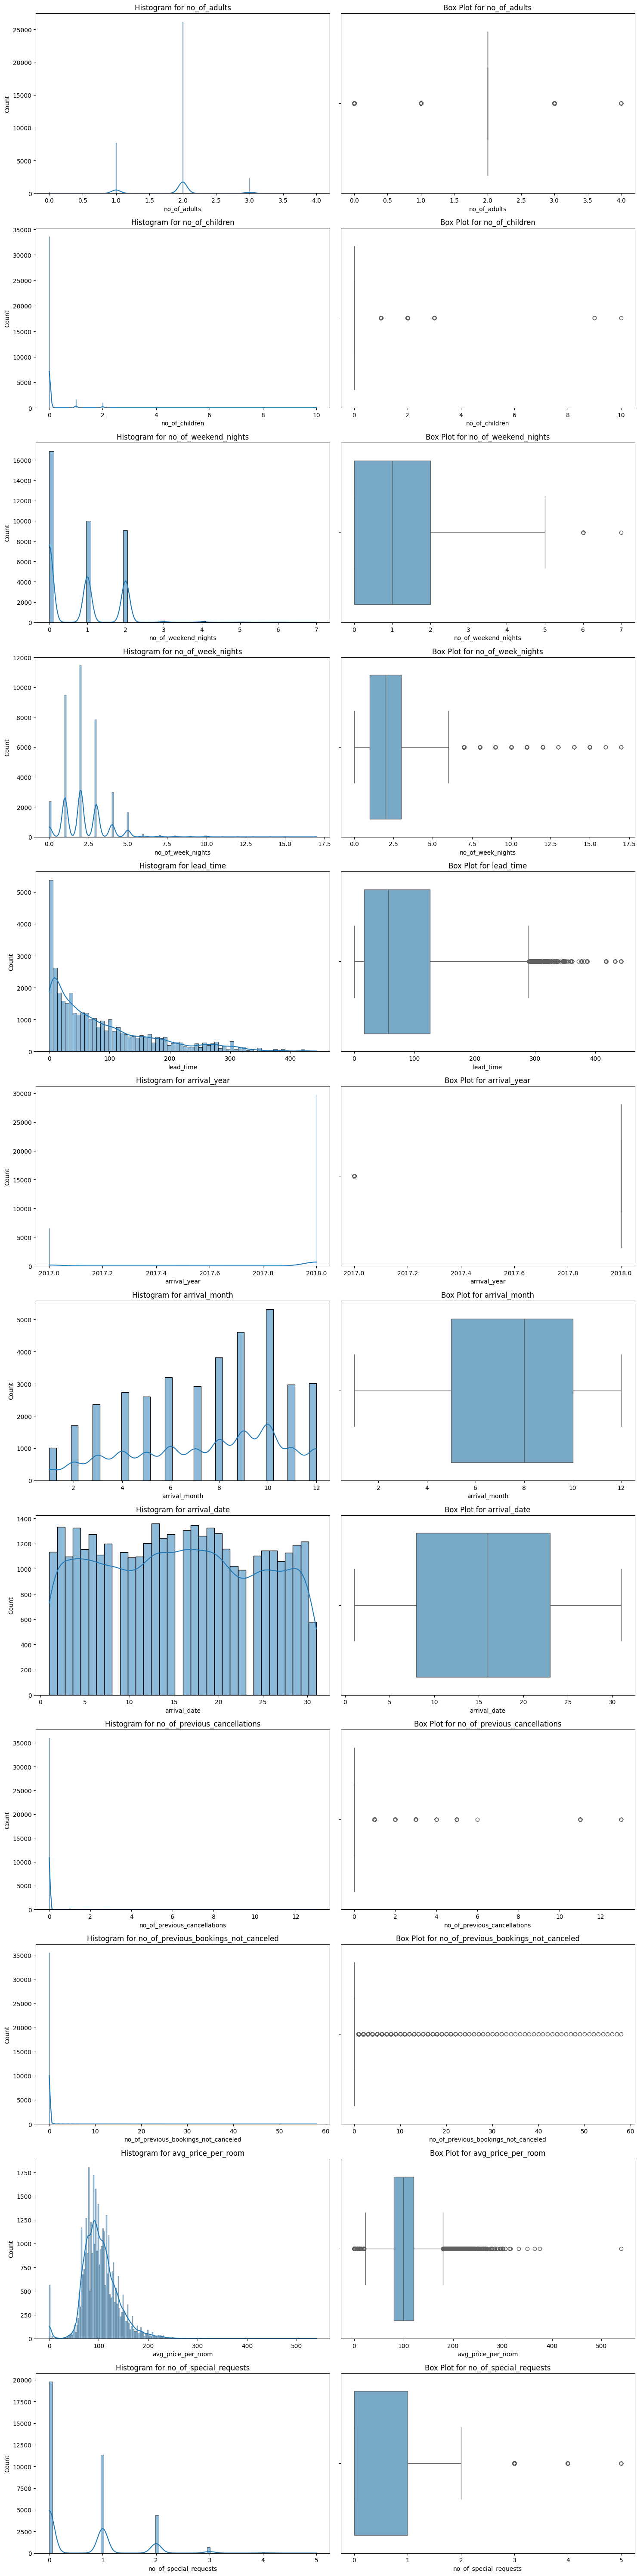

In [152]:
num_plot_dist(df , num_cols)

#### Handling outliers

In [153]:
def handling_outliers(df,columns):
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)

        IQR = Q3-Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df


In [154]:
df.columns

Index(['Booking_ID', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status'],
      dtype='str')

In [155]:
outlier_has_columns = ['no_of_special_requests','avg_price_per_room','lead_time','no_of_weekend_nights','no_of_week_nights']

In [156]:
df_clean = handling_outliers(df, outlier_has_columns)

In [157]:
df_clean.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [158]:
def num_plot_dist(df_clean , num_features):
    fig , axes = plt.subplots(len(num_features),2,figsize=(15,len(num_features)*5))
    if len(num_features)==1:
        axes=[axes]
    
    for i,column in enumerate(num_features):
        sns.histplot(data=df_clean , x=column , ax=axes[i][0] , kde=True , palette="Blues" )
        axes[i][0].set_title(f"Histogram for {column}")

        sns.boxplot(data=df_clean , x=column , ax=axes[i][1] , palette="Blues")
        axes[i][1].set_title(f"Box Plot for {column}")
    
    plt.tight_layout()
    plt.show()

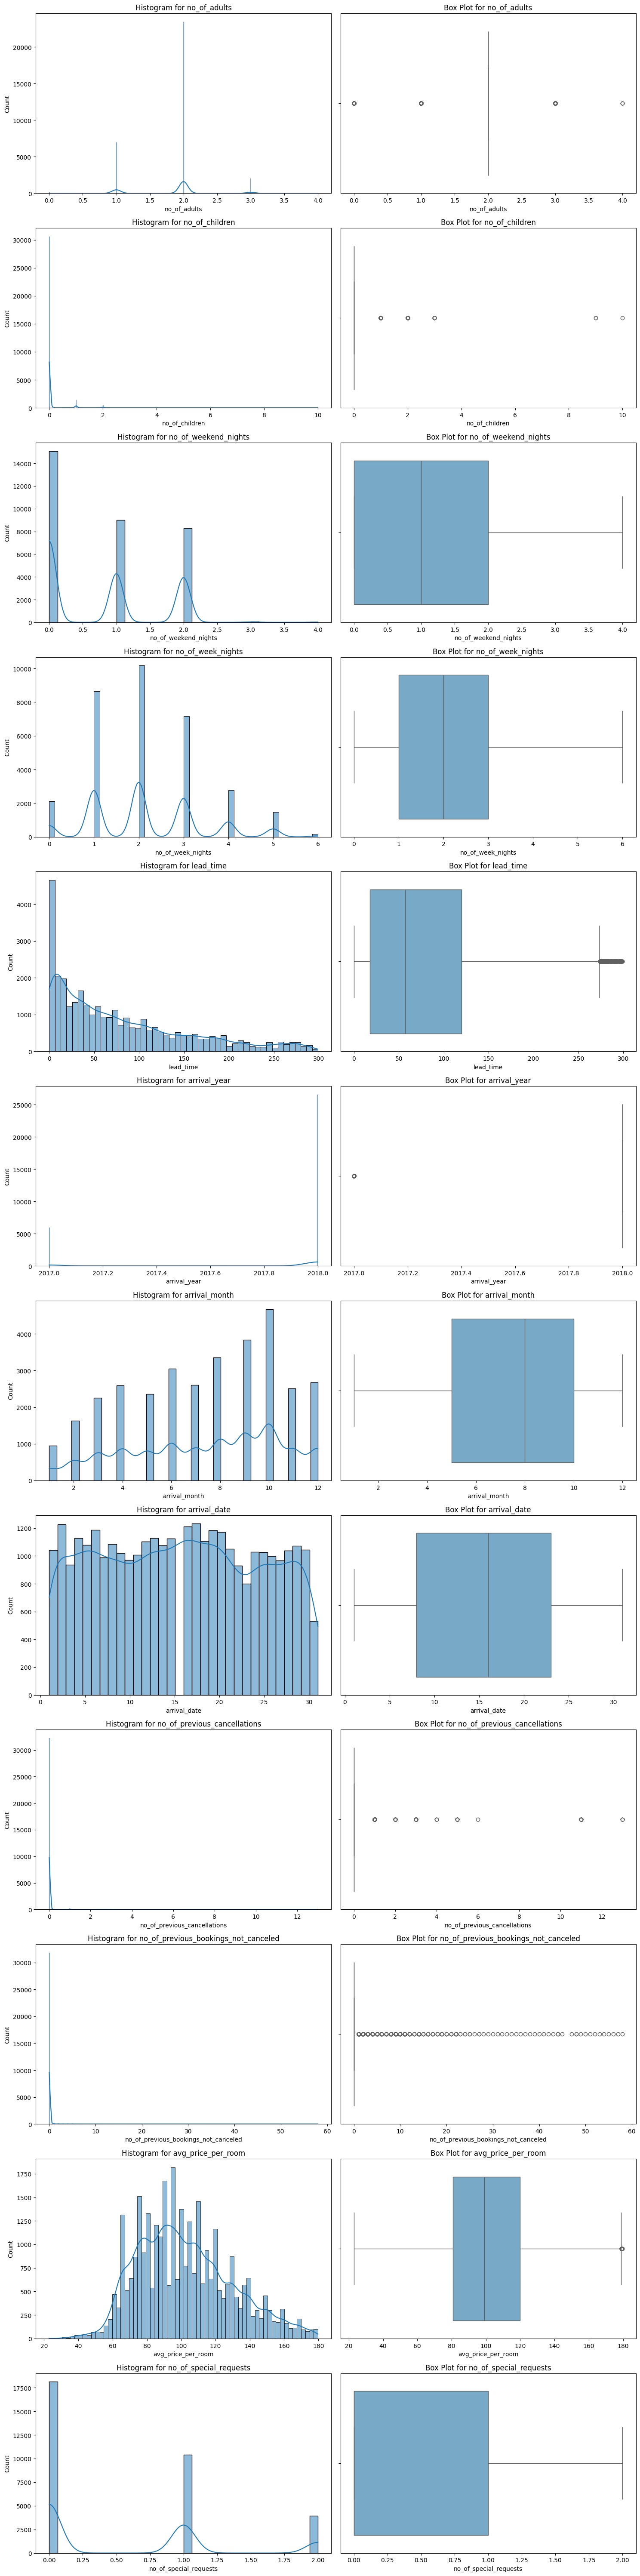

In [159]:
num_plot_dist(df_clean , num_cols)

In [160]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 32501 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            32501 non-null  str    
 1   no_of_adults                          32501 non-null  int64  
 2   no_of_children                        32501 non-null  int64  
 3   no_of_weekend_nights                  32501 non-null  int64  
 4   no_of_week_nights                     32501 non-null  int64  
 5   type_of_meal_plan                     32501 non-null  str    
 6   required_car_parking_space            32501 non-null  int64  
 7   room_type_reserved                    32501 non-null  str    
 8   lead_time                             32501 non-null  int64  
 9   arrival_year                          32501 non-null  int64  
 10  arrival_month                         32501 non-null  int64  
 11  arrival_date                   

In [161]:
# String casing

string_cols = df_clean.select_dtypes(include="str")

for col in string_cols:
    df_clean[col] = df_clean[col].str.lower()

In [162]:
# This creates a new DataFrame containing only the "bad" data
rejected_records1 = df_clean[df_clean['avg_price_per_room'] <= 0]


In [163]:
if not rejected_records1.empty:
    print("Found invalid records:")
    print(rejected_records1)


In [164]:
df_clean['arrival_full_date'] = pd.to_datetime(
    df_clean['arrival_year'].astype(str) + '-' +
    df_clean['arrival_month'].astype(str) + '-' +
    df_clean['arrival_date'].astype(str),
    errors='coerce'
)

In [167]:
df_clean[df_clean['arrival_full_date'].isna()]

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,arrival_full_date
2626,inn02627,2,0,1,5,meal plan 1,0,room_type 1,104,2018,2,29,online,1,1,0,61.43,0,canceled,NaT
3677,inn03678,1,0,1,3,meal plan 1,0,room_type 1,21,2018,2,29,online,0,0,0,102.05,0,canceled,NaT
5600,inn05601,2,0,1,3,meal plan 1,0,room_type 1,24,2018,2,29,offline,0,0,0,45.50,0,not_canceled,NaT
6343,inn06344,1,0,1,1,meal plan 1,0,room_type 1,117,2018,2,29,offline,0,0,0,76.00,0,not_canceled,NaT
7648,inn07649,2,1,1,5,meal plan 1,0,room_type 1,35,2018,2,29,online,0,0,0,98.10,1,canceled,NaT
8989,inn08990,1,0,1,2,meal plan 1,0,room_type 1,117,2018,2,29,offline,0,0,0,76.00,0,not_canceled,NaT
9245,inn09246,2,0,1,3,meal plan 1,0,room_type 4,15,2018,2,29,online,0,0,0,85.55,1,not_canceled,NaT
9664,inn09665,1,0,1,0,meal plan 1,0,room_type 4,21,2018,2,29,online,0,0,0,117.00,0,not_canceled,NaT
9934,inn09935,1,0,1,2,meal plan 1,0,room_type 1,45,2018,2,29,online,0,0,0,76.30,0,not_canceled,NaT
10593,inn10594,2,0,1,3,meal plan 1,1,room_type 4,47,2018,2,29,online,0,0,0,99.40,1,not_canceled,NaT


In [171]:
df_clean.drop(['arrival_year','arrival_month','arrival_date'], axis=1, inplace=True)

In [172]:
records=df_clean['arrival_full_date'].isna().sum()
print(records)

32


In [173]:
df_clean.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,arrival_full_date
0,inn00001,2,0,1,2,meal plan 1,0,room_type 1,224,offline,0,0,0,65.00,0,not_canceled,2017-10-02
1,inn00002,2,0,2,3,not selected,0,room_type 1,5,online,0,0,0,106.68,1,not_canceled,2018-11-06
2,inn00003,1,0,2,1,meal plan 1,0,room_type 1,1,online,0,0,0,60.00,0,canceled,2018-02-28
3,inn00004,2,0,0,2,meal plan 1,0,room_type 1,211,online,0,0,0,100.00,0,canceled,2018-05-20
4,inn00005,2,0,1,1,not selected,0,room_type 1,48,online,0,0,0,94.50,0,canceled,2018-04-11


In [174]:
df_clean = df_clean.dropna(subset=['arrival_full_date'])

In [176]:
df_clean.tail()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,arrival_full_date
36270,inn36271,3,0,2,6,meal plan 1,0,room_type 4,85,online,0,0,0,167.80,1,not_canceled,2018-08-03
36271,inn36272,2,0,1,3,meal plan 1,0,room_type 1,228,online,0,0,0,90.95,2,canceled,2018-10-17
36272,inn36273,2,0,2,6,meal plan 1,0,room_type 1,148,online,0,0,0,98.39,2,not_canceled,2018-07-01
36273,inn36274,2,0,0,3,not selected,0,room_type 1,63,online,0,0,0,94.50,0,canceled,2018-04-21
36274,inn36275,2,0,1,2,meal plan 1,0,room_type 1,207,offline,0,0,0,161.67,0,not_canceled,2018-12-30


In [177]:
df_clean.value_counts()

Booking_ID  no_of_adults  no_of_children  no_of_weekend_nights  no_of_week_nights  type_of_meal_plan  required_car_parking_space  room_type_reserved  lead_time  market_segment_type  repeated_guest  no_of_previous_cancellations  no_of_previous_bookings_not_canceled  avg_price_per_room  no_of_special_requests  booking_status  arrival_full_date
inn00001    2             0               1                     2                  meal plan 1        0                           room_type 1         224        offline              0               0                             0                                     65.00               0                       not_canceled    2017-10-02           1
inn00002    2             0               2                     3                  not selected       0                           room_type 1         5          online               0               0                             0                                     106.68              1                    